In [1]:
import os
import sys 
import astropy.units as u
import time 
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd

from outflows import ImageUtilities, Outflow, PlottingUtilities, RegionUtilities
from astropy.io import fits, ascii
from astropy.coordinates import SkyCoord
from astropy.stats import SigmaClip
from astropy.wcs import WCS

from astrodendro import Dendrogram
from astrodendro.analysis import PPStatistic
from photutils.background import StdBackgroundRMS
from matplotlib.widgets import Button, Slider
from glob import glob


%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib widget

## Load images

In [3]:
G339_ALMA_hdu = fits.open("./example_images/G339_ALMA_B6_cont.fits")[0]
SerpensMain_NIRCam_hdu = fits.open("./example_images/SerpensMain_NIRCam_f480M.fits")[1]

## Define central coordinates of sources we want to compute the dendrogram of

In [4]:
G339_coords = [
    SkyCoord(ra=253.0194147, dec=-46.14276169, unit=u.deg),
    SkyCoord(ra=253.0160804, dec=-46.1408412, unit=u.deg),
]
# Coordinates of driving source (or central position if none identified)
SerpensMain_coords = [
                  SkyCoord(277.45296, 1.28233, unit=u.deg, frame='icrs'),
                  SkyCoord(277.45742, 1.25581, unit=u.deg, frame='icrs'),
                  SkyCoord(277.45946, 1.23919, unit=u.deg, frame='icrs')]

# Angles the images need to be rotated by to make the outflow roughly horizontal
outflow_rotation_angles = [-72.6858105638866,
                           -49.485810563886616, -49.08581056388661]

# Select dendrograms structures for G339

In [19]:
G339_noise = StdBackgroundRMS(sigma_clip=SigmaClip(sigma=5)).calc_background_rms(G339_ALMA_hdu.data)

for i, coord in enumerate(G339_coords):
    source = Outflow(
        image_hdu=G339_ALMA_hdu,
        central_coord=coord,
        rotation_angle=0,
        window_x_arcsec=2,
        window_y_arcsec=2,
    )

    print(sys.getsizeof(source))
    # dendrogram = source.compute_dendrogram(min_npix=10, min_value_factor=1, mask_bright=False, noise=G339_noise)
    # source.select_structures(dendrogram)
    # # source.plot_outflow(stretch="linear")

48
48


# Select dendrograms structures for Serpens Main

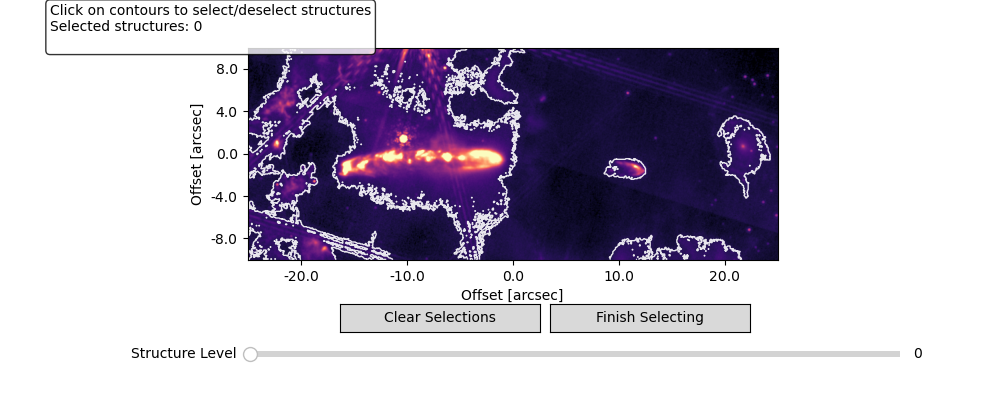

In [10]:
SerpensMain_noise = StdBackgroundRMS(sigma_clip=SigmaClip(sigma=2)).calc_background_rms(SerpensMain_NIRCam_hdu.data)
# outflow_rotation_angles = [-43.485810563886616, -55.08581056388661, -72.6858105638866]

for i, coord in enumerate([SerpensMain_coords[0]]):
    source = Outflow(
        image_hdu=SerpensMain_NIRCam_hdu,
        central_coord=coord,
        rotation_angle=outflow_rotation_angles[i],
        window_x_arcsec=50,
        window_y_arcsec=20,
    )
    dendrogram = source.compute_dendrogram(min_value_factor=3, min_npix=1000, mask_bright=False, noise=SerpensMain_noise)
    source.select_structures(dendrogram)
    # source.plot_outflow(stretch="linear")